In [17]:
import pandas as pd
import numpy as np

# 1. Loading the raw dataset with laboratory inconsistencies
raw_mining_data = {
    'sample_id': ['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08'],
    'rock_type': ['Basalt', 'Quartzite', 'Basalt', 'Granite', 'Basalt', 'Quartzite', 'Schist', 'Basalt'],
    'Au_g_t': [0.5, 1.2, 'below detection', 0.8, 25.0, np.nan, 0.4, 0.9], 
    'Cu_percent': [0.02, 0.05, 0.03, 'N.A.', 0.01, 0.12, 0.04, 0.03]
}

df = pd.DataFrame(raw_mining_data)

# 2. Convert columns to numeric, forcing errors to NaN
# This is crucial because 'below detection' or 'N.A.' are strings
df['Au_g_t'] = pd.to_numeric(df['Au_g_t'], errors='coerce')
df['Cu_percent'] = pd.to_numeric(df['Cu_percent'], errors='coerce')

print("Cleaned Dataframe (Stage 1):")
print(df)

Cleaned Dataframe (Stage 1):
  sample_id  rock_type  Au_g_t  Cu_percent
0       S01     Basalt     0.5        0.02
1       S02  Quartzite     1.2        0.05
2       S03     Basalt     NaN        0.03
3       S04    Granite     0.8         NaN
4       S05     Basalt    25.0        0.01
5       S06  Quartzite     NaN        0.12
6       S07     Schist     0.4        0.04
7       S08     Basalt     0.9        0.03


In [18]:
# Fill NaN values with 0
df_filled = df.copy()
df_filled['Au_g_t'] = df_filled['Au_g_t'].fillna(0)

# Define mean_gold here so it's available for the next cell
mean_gold = df_filled['Au_g_t'].mean()

In [19]:
# 1. Calculating Standard Deviation (Spread)
std_gold = df_filled['Au_g_t'].std()

print(f"Standard Deviation of Gold: {std_gold:.3f}")

# 2. Understanding Coefficient of Variation (CV)
# CV = (Standard Deviation / Mean)
cv_gold = std_gold / mean_gold
print(f"Coefficient of Variation (CV): {cv_gold:.2f}")

Standard Deviation of Gold: 8.657
Coefficient of Variation (CV): 2.40


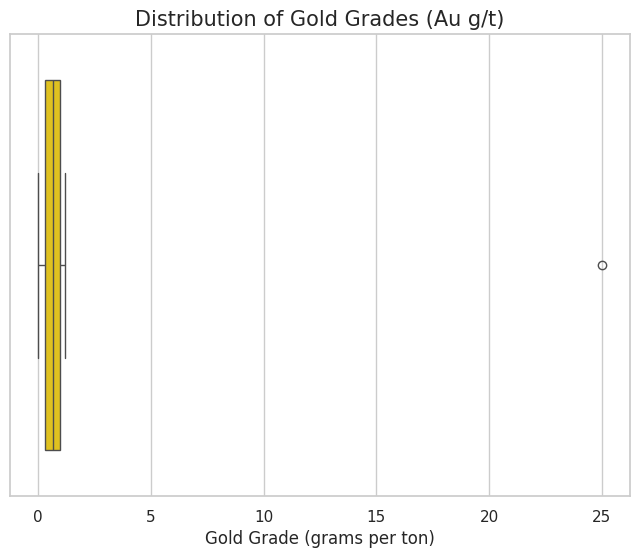

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Create a boxplot for Gold grades
sns.boxplot(x=df_filled['Au_g_t'], color='gold')

# Add titles and labels in English
plt.title('Distribution of Gold Grades (Au g/t)', fontsize=15)
plt.xlabel('Gold Grade (grams per ton)')

plt.show()

Correlation Matrix:
              Au_g_t  Cu_percent
Au_g_t      1.000000   -0.413576
Cu_percent -0.413576    1.000000

Pearson Correlation between Au and Cu: -0.414


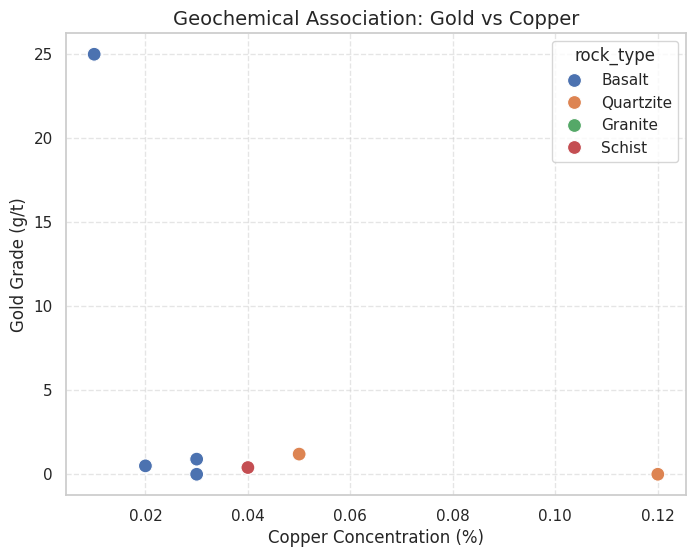

In [21]:
# 1. Calculating the Pearson Correlation matrix
# We select only the mineral columns
correlation_matrix = df_filled[['Au_g_t', 'Cu_percent']].corr()

print("Correlation Matrix:")
print(correlation_matrix)

# 2. Extracting the specific value
pearson_val = correlation_matrix.iloc[0, 1]
print(f"\nPearson Correlation between Au and Cu: {pearson_val:.3f}")

# 3. Visualizing the relationship with a Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_filled, x='Cu_percent', y='Au_g_t', hue='rock_type', s=100)

plt.title('Geochemical Association: Gold vs Copper', fontsize=14)
plt.xlabel('Copper Concentration (%)')
plt.ylabel('Gold Grade (g/t)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


New Pearson Correlation (without outlier): -0.363


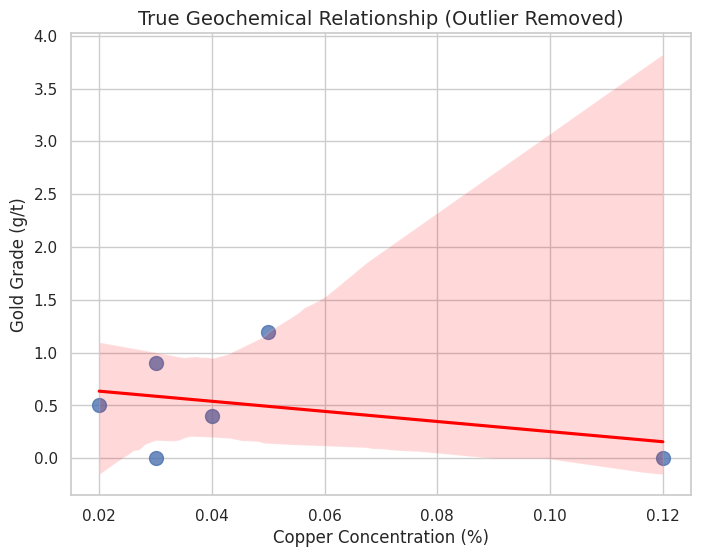

In [22]:
# 1. Removing the outlier (filtering samples with Au < 10 g/t)
df_no_outliers = df_filled[df_filled['Au_g_t'] < 10]

# 2. Recalculating Pearson Correlation on the "typical" ore
clean_correlation = df_no_outliers[['Au_g_t', 'Cu_percent']].corr()
new_pearson = clean_correlation.iloc[0, 1]

print(f"New Pearson Correlation (without outlier): {new_pearson:.3f}")

# 3. Visualizing the 'Clean' relationship
plt.figure(figsize=(8, 6))
sns.regplot(data=df_no_outliers, x='Cu_percent', y='Au_g_t', scatter_kws={'s':100}, line_kws={'color':'red'})

plt.title('True Geochemical Relationship (Outlier Removed)', fontsize=14)
plt.xlabel('Copper Concentration (%)')
plt.ylabel('Gold Grade (g/t)')
plt.show()